# Step 2: 단변량 분석 완료

## 목표
- Step 1에서 확인하지 않은 모든 변수의 단변량 분포 확인
- Time, Genre, Year, Director, Writer 분포 분석
- 유저/아이템 상호작용 분포 시각화 추가

In [1]:
import pandas as pd
import numpy as np
import json
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (필요시)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
DATA_PATH = '../data/train/'

print("Setup complete.")

Setup complete.


In [2]:
# 데이터 로드
ratings = pd.read_csv(os.path.join(DATA_PATH, 'train_ratings.csv'))
titles = pd.read_csv(os.path.join(DATA_PATH, 'titles.tsv'), sep='\t')
years = pd.read_csv(os.path.join(DATA_PATH, 'years.tsv'), sep='\t')
genres = pd.read_csv(os.path.join(DATA_PATH, 'genres.tsv'), sep='\t')
directors = pd.read_csv(os.path.join(DATA_PATH, 'directors.tsv'), sep='\t')
writers = pd.read_csv(os.path.join(DATA_PATH, 'writers.tsv'), sep='\t')

with open(os.path.join(DATA_PATH, 'Ml_item2attributes.json'), 'r') as f:
    item2attr = json.load(f)

print("Data loaded.")
print(f"ratings: {ratings.shape}")
print(f"genres: {genres.shape}")
print(f"years: {years.shape}")
print(f"directors: {directors.shape}")
print(f"writers: {writers.shape}")

Data loaded.
ratings: (5154471, 3)
genres: (15933, 2)
years: (6799, 2)
directors: (5905, 2)
writers: (11306, 2)


---
## 1. 유저/아이템 상호작용 분포 시각화
Step 1에서 통계량만 확인했으므로, 분포 형태를 시각화

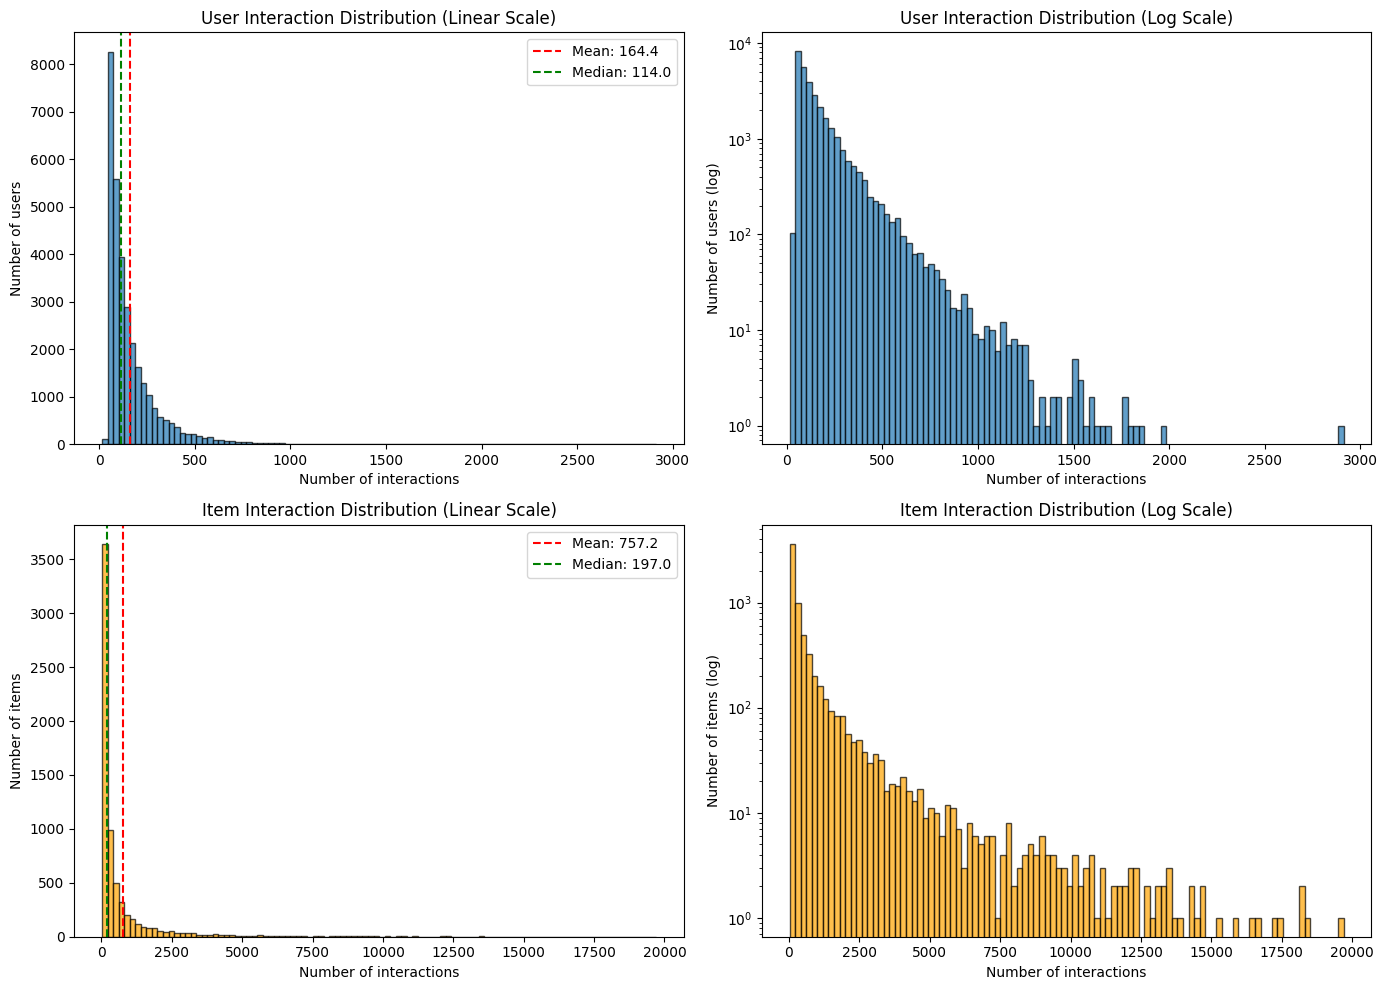

[Long-tail 분석]

--- 아이템 기준 ---
  상위 1% 아이템 (68개)이 전체 상호작용의 16.4% 차지
  상위 5% 아이템 (340개)이 전체 상호작용의 44.7% 차지
  상위 10% 아이템 (680개)이 전체 상호작용의 61.0% 차지
  상위 20% 아이템 (1361개)이 전체 상호작용의 77.2% 차지

--- 유저 기준 ---
  상위 1% 유저 (313명)가 전체 상호작용의 6.0% 차지
  상위 5% 유저 (1568명)가 전체 상호작용의 19.7% 차지
  상위 10% 유저 (3136명)가 전체 상호작용의 31.4% 차지
  상위 20% 유저 (6272명)가 전체 상호작용의 48.1% 차지


In [3]:
# 유저당 상호작용 수
user_counts = ratings.groupby('user').size()
# 아이템당 상호작용 수
item_counts = ratings.groupby('item').size()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1-1. 유저당 상호작용 수 (원본)
axes[0, 0].hist(user_counts, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Number of interactions')
axes[0, 0].set_ylabel('Number of users')
axes[0, 0].set_title('User Interaction Distribution (Linear Scale)')
axes[0, 0].axvline(user_counts.mean(), color='red', linestyle='--', label=f'Mean: {user_counts.mean():.1f}')
axes[0, 0].axvline(user_counts.median(), color='green', linestyle='--', label=f'Median: {user_counts.median():.1f}')
axes[0, 0].legend()

# 1-2. 유저당 상호작용 수 (로그 스케일)
axes[0, 1].hist(user_counts, bins=100, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Number of interactions')
axes[0, 1].set_ylabel('Number of users (log)')
axes[0, 1].set_title('User Interaction Distribution (Log Scale)')
axes[0, 1].set_yscale('log')

# 1-3. 아이템당 상호작용 수 (원본)
axes[1, 0].hist(item_counts, bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_xlabel('Number of interactions')
axes[1, 0].set_ylabel('Number of items')
axes[1, 0].set_title('Item Interaction Distribution (Linear Scale)')
axes[1, 0].axvline(item_counts.mean(), color='red', linestyle='--', label=f'Mean: {item_counts.mean():.1f}')
axes[1, 0].axvline(item_counts.median(), color='green', linestyle='--', label=f'Median: {item_counts.median():.1f}')
axes[1, 0].legend()

# 1-4. 아이템당 상호작용 수 (로그 스케일)
axes[1, 1].hist(item_counts, bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Number of interactions')
axes[1, 1].set_ylabel('Number of items (log)')
axes[1, 1].set_title('Item Interaction Distribution (Log Scale)')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

# Long-tail 정량화
print("=" * 60)
print("[Long-tail 분석]")
print("\n--- 아이템 기준 ---")
item_counts_sorted = item_counts.sort_values(ascending=False)
total_interactions = item_counts_sorted.sum()
for pct in [1, 5, 10, 20]:
    top_n = int(len(item_counts_sorted) * pct / 100)
    top_interactions = item_counts_sorted.head(top_n).sum()
    print(f"  상위 {pct}% 아이템 ({top_n}개)이 전체 상호작용의 {top_interactions/total_interactions*100:.1f}% 차지")

print("\n--- 유저 기준 ---")
user_counts_sorted = user_counts.sort_values(ascending=False)
for pct in [1, 5, 10, 20]:
    top_n = int(len(user_counts_sorted) * pct / 100)
    top_interactions = user_counts_sorted.head(top_n).sum()
    print(f"  상위 {pct}% 유저 ({top_n}명)가 전체 상호작용의 {top_interactions/total_interactions*100:.1f}% 차지")

---
## 2. Time (timestamp) 분포 분석

In [4]:
# timestamp를 datetime으로 변환
ratings['datetime'] = pd.to_datetime(ratings['time'], unit='s')
ratings['year'] = ratings['datetime'].dt.year
ratings['month'] = ratings['datetime'].dt.month
ratings['dayofweek'] = ratings['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
ratings['hour'] = ratings['datetime'].dt.hour

print("Datetime features created.")
print(ratings[['time', 'datetime', 'year', 'month', 'dayofweek', 'hour']].head(10))

Datetime features created.
         time            datetime  year  month  dayofweek  hour
0  1230782529 2009-01-01 04:02:09  2009      1          3     4
1  1230782534 2009-01-01 04:02:14  2009      1          3     4
2  1230782539 2009-01-01 04:02:19  2009      1          3     4
3  1230782542 2009-01-01 04:02:22  2009      1          3     4
4  1230782563 2009-01-01 04:02:43  2009      1          3     4
5  1230782583 2009-01-01 04:03:03  2009      1          3     4
6  1230782646 2009-01-01 04:04:06  2009      1          3     4
7  1230782656 2009-01-01 04:04:16  2009      1          3     4
8  1230782694 2009-01-01 04:04:54  2009      1          3     4
9  1230782719 2009-01-01 04:05:19  2009      1          3     4


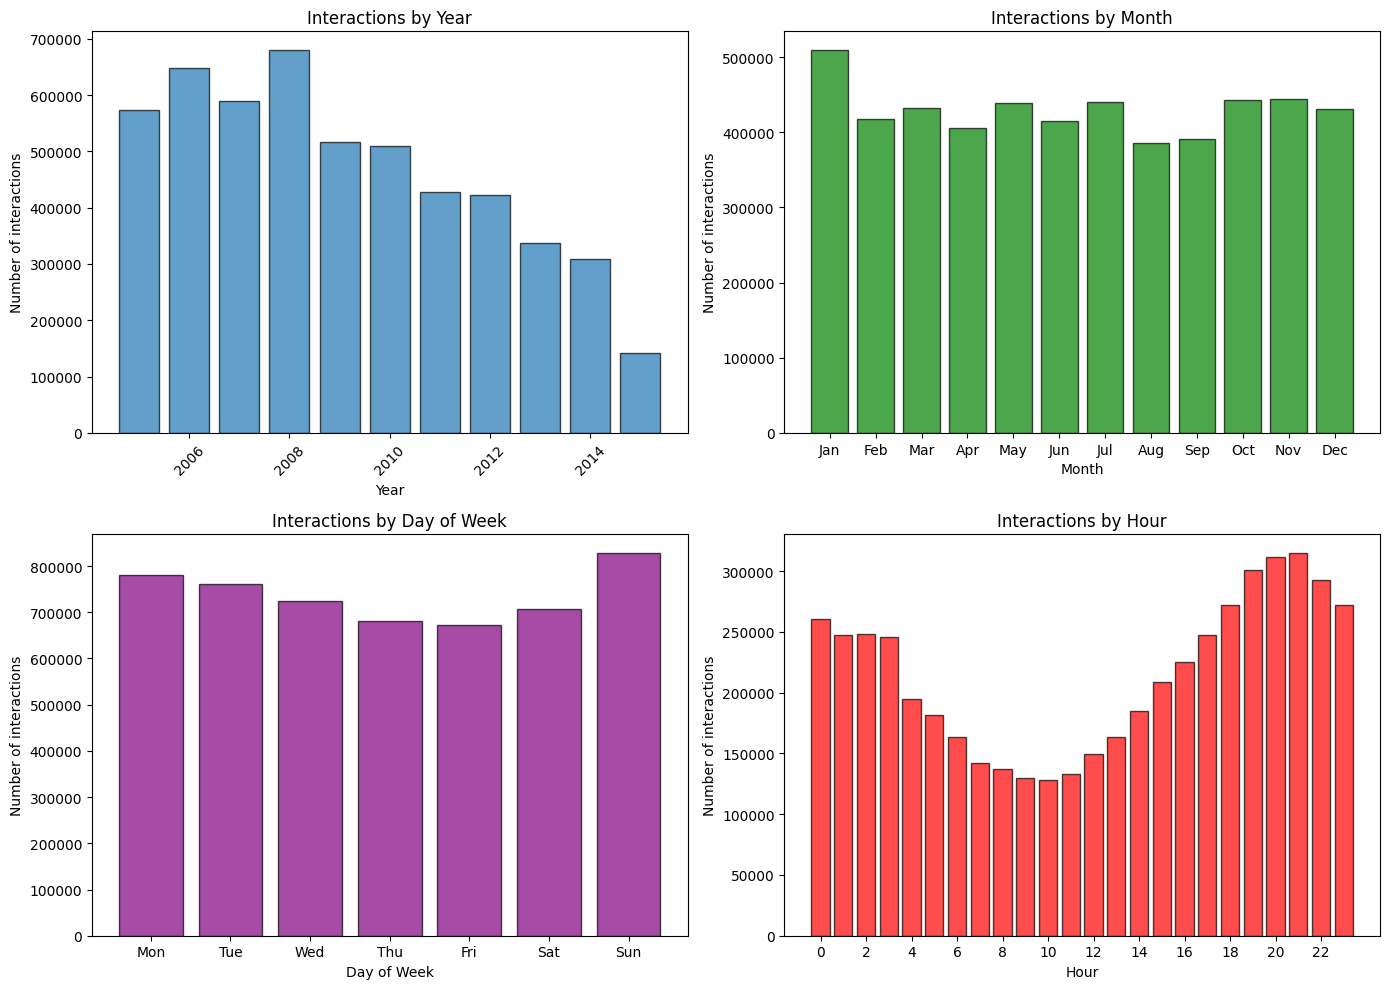

In [5]:
# 2-1. 연도별 상호작용 수
year_counts = ratings['year'].value_counts().sort_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(year_counts.index, year_counts.values, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of interactions')
axes[0, 0].set_title('Interactions by Year')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2-2. 월별 상호작용 수
month_counts = ratings['month'].value_counts().sort_index()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0, 1].bar(month_counts.index, month_counts.values, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of interactions')
axes[0, 1].set_title('Interactions by Month')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_labels)

# 2-3. 요일별 상호작용 수
dow_counts = ratings['dayofweek'].value_counts().sort_index()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 0].bar(dow_counts.index, dow_counts.values, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Number of interactions')
axes[1, 0].set_title('Interactions by Day of Week')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(dow_labels)

# 2-4. 시간대별 상호작용 수
hour_counts = ratings['hour'].value_counts().sort_index()
axes[1, 1].bar(hour_counts.index, hour_counts.values, edgecolor='black', alpha=0.7, color='red')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Number of interactions')
axes[1, 1].set_title('Interactions by Hour')
axes[1, 1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

In [6]:
# Time 분포 통계 출력
print("=" * 60)
print("[Time 분포 통계]")

print("\n--- 연도별 상호작용 수 ---")
for year, count in year_counts.items():
    print(f"  {year}: {count:,} ({count/len(ratings)*100:.1f}%)")

print("\n--- 월별 상호작용 수 ---")
for month, count in month_counts.items():
    print(f"  {month_labels[month-1]}: {count:,} ({count/len(ratings)*100:.1f}%)")

print("\n--- 요일별 상호작용 수 ---")
for dow, count in dow_counts.items():
    print(f"  {dow_labels[dow]}: {count:,} ({count/len(ratings)*100:.1f}%)")

print("\n--- 시간대별 상호작용 비율 ---")
time_periods = {
    'Dawn (0-6)': ratings[(ratings['hour'] >= 0) & (ratings['hour'] < 6)].shape[0],
    'Morning (6-12)': ratings[(ratings['hour'] >= 6) & (ratings['hour'] < 12)].shape[0],
    'Afternoon (12-18)': ratings[(ratings['hour'] >= 12) & (ratings['hour'] < 18)].shape[0],
    'Evening (18-24)': ratings[(ratings['hour'] >= 18) & (ratings['hour'] < 24)].shape[0]
}
for period, count in time_periods.items():
    print(f"  {period}: {count:,} ({count/len(ratings)*100:.1f}%)")

[Time 분포 통계]

--- 연도별 상호작용 수 ---
  2005: 572,894 (11.1%)
  2006: 647,240 (12.6%)
  2007: 589,945 (11.4%)
  2008: 679,269 (13.2%)
  2009: 517,366 (10.0%)
  2010: 510,385 (9.9%)
  2011: 427,103 (8.3%)
  2012: 421,942 (8.2%)
  2013: 338,109 (6.6%)
  2014: 308,281 (6.0%)
  2015: 141,937 (2.8%)

--- 월별 상호작용 수 ---
  Jan: 508,889 (9.9%)
  Feb: 417,357 (8.1%)
  Mar: 432,249 (8.4%)
  Apr: 406,257 (7.9%)
  May: 439,160 (8.5%)
  Jun: 414,722 (8.0%)
  Jul: 440,935 (8.6%)
  Aug: 386,369 (7.5%)
  Sep: 390,955 (7.6%)
  Oct: 442,310 (8.6%)
  Nov: 444,009 (8.6%)
  Dec: 431,259 (8.4%)

--- 요일별 상호작용 수 ---
  Mon: 779,835 (15.1%)
  Tue: 760,619 (14.8%)
  Wed: 725,169 (14.1%)
  Thu: 681,803 (13.2%)
  Fri: 671,527 (13.0%)
  Sat: 708,024 (13.7%)
  Sun: 827,494 (16.1%)

--- 시간대별 상호작용 비율 ---
  Dawn (0-6): 1,377,788 (26.7%)
  Morning (6-12): 833,923 (16.2%)
  Afternoon (12-18): 1,178,996 (22.9%)
  Evening (18-24): 1,763,764 (34.2%)


---
## 3. Genre 분포 분석

In [7]:
# 3-1. 장르별 아이템 수
genre_item_counts = genres.groupby('genre')['item'].nunique().sort_values(ascending=False)

print("=" * 60)
print("[장르별 아이템 수]")
print(f"총 장르 수: {genres['genre'].nunique()}")
print(f"\n장르별 아이템 수:")
for genre, count in genre_item_counts.items():
    print(f"  {genre}: {count}개")

[장르별 아이템 수]
총 장르 수: 18

장르별 아이템 수:
  Drama: 3490개
  Comedy: 2408개
  Thriller: 1466개
  Romance: 1251개
  Action: 1246개
  Crime: 924개
  Adventure: 891개
  Sci-Fi: 653개
  Horror: 602개
  Fantasy: 557개
  Mystery: 471개
  Children: 432개
  Animation: 355개
  War: 346개
  Documentary: 323개
  Musical: 282개
  Western: 139개
  Film-Noir: 97개


In [8]:
# 3-2. 장르별 상호작용 수
# ratings와 genres를 조인하여 장르별 상호작용 수 계산
ratings_with_genre = ratings.merge(genres, left_on='item', right_on='item', how='left')
genre_interaction_counts = ratings_with_genre.groupby('genre').size().sort_values(ascending=False)

print("=" * 60)
print("[장르별 상호작용 수]")
for genre, count in genre_interaction_counts.items():
    print(f"  {genre}: {count:,}")

[장르별 상호작용 수]
  Drama: 2,511,407
  Comedy: 1,719,017
  Action: 1,504,902
  Thriller: 1,435,678
  Adventure: 1,203,283
  Crime: 1,014,480
  Romance: 893,843
  Sci-Fi: 857,851
  Fantasy: 617,807
  Mystery: 493,005
  Children: 397,929
  Animation: 370,761
  Horror: 343,730
  War: 307,170
  Musical: 199,635
  Western: 95,374
  Documentary: 90,050
  Film-Noir: 70,402


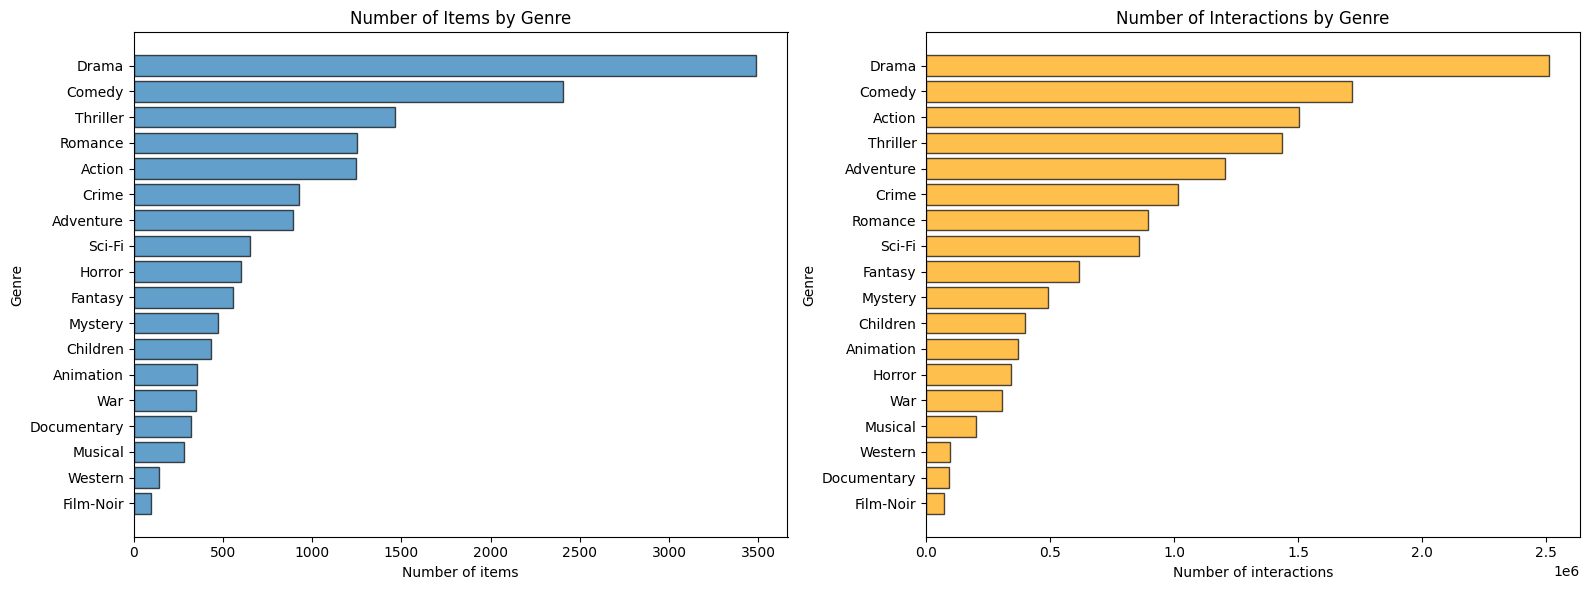

In [9]:
# 3-3. 장르 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 장르별 아이템 수
axes[0].barh(genre_item_counts.index, genre_item_counts.values, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of items')
axes[0].set_ylabel('Genre')
axes[0].set_title('Number of Items by Genre')
axes[0].invert_yaxis()

# 장르별 상호작용 수
axes[1].barh(genre_interaction_counts.index, genre_interaction_counts.values, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Number of interactions')
axes[1].set_ylabel('Genre')
axes[1].set_title('Number of Interactions by Genre')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

[아이템당 장르 수 분포]
평균: 2.34
중앙값: 2
최소: 1
최대: 10

장르 수별 아이템 분포:
  1개 장르: 1756개 아이템 (25.8%)
  2개 장르: 2280개 아이템 (33.5%)
  3개 장르: 1786개 아이템 (26.2%)
  4개 장르: 726개 아이템 (10.7%)
  5개 장르: 212개 아이템 (3.1%)
  6개 장르: 38개 아이템 (0.6%)
  7개 장르: 7개 아이템 (0.1%)
  8개 장르: 1개 아이템 (0.0%)
  10개 장르: 1개 아이템 (0.0%)


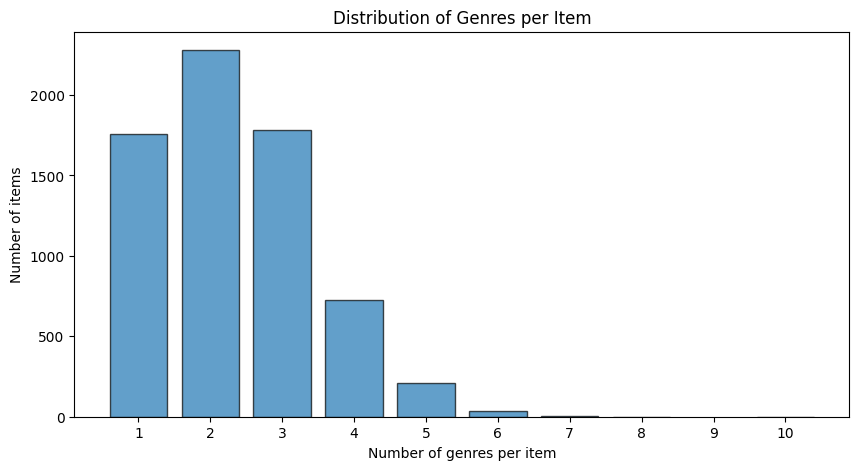

In [10]:
# 3-4. 아이템당 장르 수 분포 (멀티 장르)
genres_per_item = genres.groupby('item').size()

print("=" * 60)
print("[아이템당 장르 수 분포]")
print(f"평균: {genres_per_item.mean():.2f}")
print(f"중앙값: {genres_per_item.median():.0f}")
print(f"최소: {genres_per_item.min()}")
print(f"최대: {genres_per_item.max()}")

print("\n장르 수별 아이템 분포:")
genre_count_dist = genres_per_item.value_counts().sort_index()
for n_genres, count in genre_count_dist.items():
    print(f"  {n_genres}개 장르: {count}개 아이템 ({count/len(genres_per_item)*100:.1f}%)")

# 시각화
plt.figure(figsize=(10, 5))
plt.bar(genre_count_dist.index, genre_count_dist.values, edgecolor='black', alpha=0.7)
plt.xlabel('Number of genres per item')
plt.ylabel('Number of items')
plt.title('Distribution of Genres per Item')
plt.xticks(range(1, int(genres_per_item.max()) + 1))
plt.show()

---
## 4. Year (영화 개봉연도) 분포 분석

In [11]:
# 4-1. 개봉연도 기본 통계
print("=" * 60)
print("[영화 개봉연도 분포]")
print(f"개봉연도 범위: {years['year'].min()} ~ {years['year'].max()}")
print(f"평균: {years['year'].mean():.1f}")
print(f"중앙값: {years['year'].median():.0f}")
print(f"표준편차: {years['year'].std():.1f}")

[영화 개봉연도 분포]
개봉연도 범위: 1922 ~ 2014
평균: 1992.2
중앙값: 1999
표준편차: 19.1


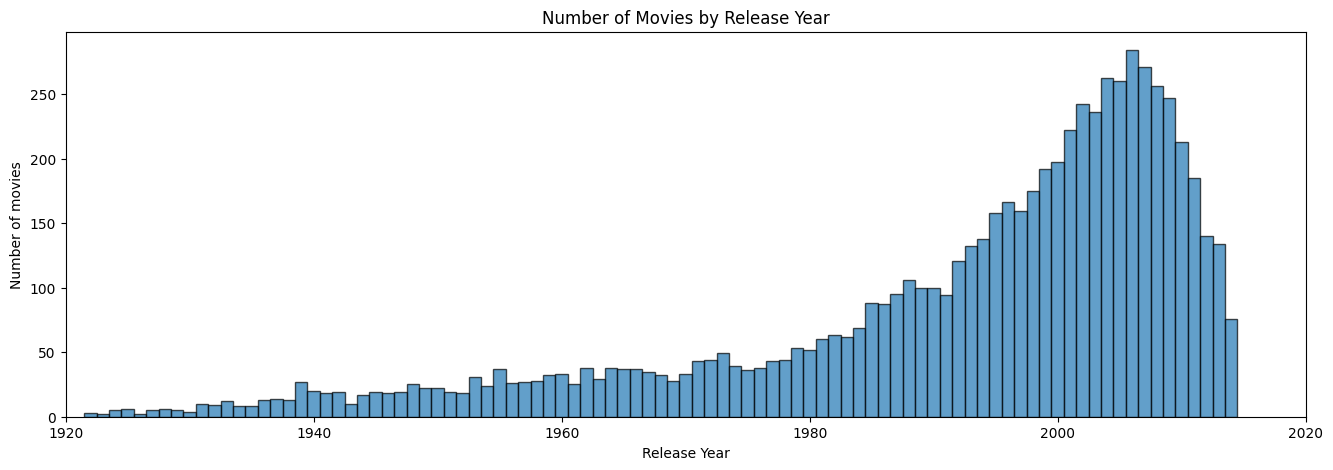

[연대별 영화 수]
  1920s: 34개 (0.5%)
  1930s: 118개 (1.7%)
  1940s: 187개 (2.8%)
  1950s: 264개 (3.9%)
  1960s: 332개 (4.9%)
  1970s: 422개 (6.2%)
  1980s: 782개 (11.5%)
  1990s: 1435개 (21.1%)
  2000s: 2477개 (36.4%)
  2010s: 748개 (11.0%)


In [12]:
# 4-2. 개봉연도별 아이템 수
release_year_counts = years['year'].value_counts().sort_index()

plt.figure(figsize=(16, 5))
plt.bar(release_year_counts.index, release_year_counts.values, edgecolor='black', alpha=0.7, width=1.0)
plt.xlabel('Release Year')
plt.ylabel('Number of movies')
plt.title('Number of Movies by Release Year')
plt.xlim(1920, 2020)
plt.show()

# 연대별 분포
print("=" * 60)
print("[연대별 영화 수]")
years['decade'] = (years['year'] // 10) * 10
decade_counts = years['decade'].value_counts().sort_index()
for decade, count in decade_counts.items():
    print(f"  {decade}s: {count}개 ({count/len(years)*100:.1f}%)")

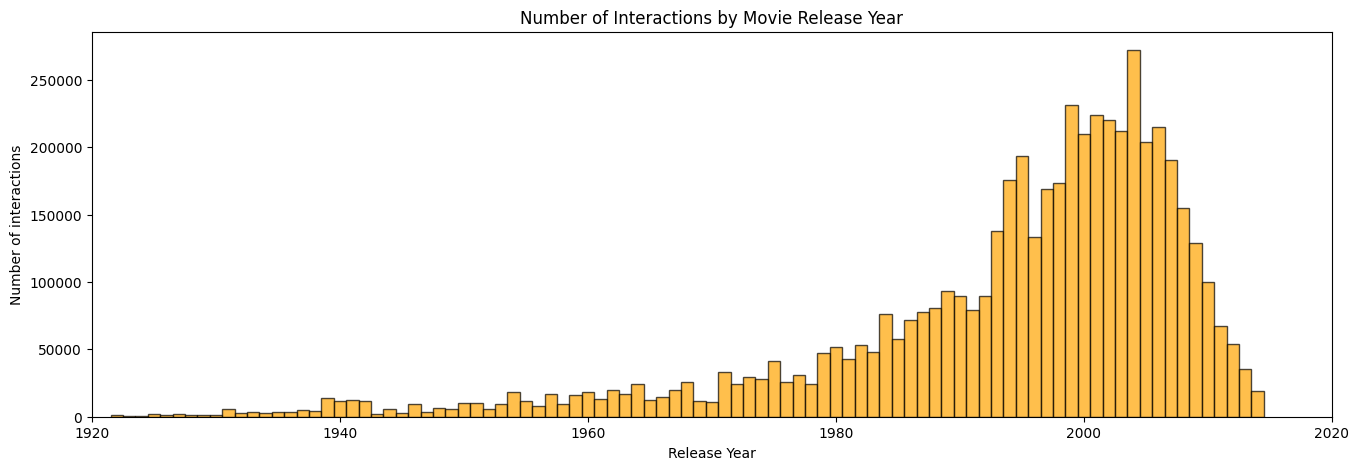

In [13]:
# 4-3. 개봉연도별 상호작용 수 (실제 시청된 양)
ratings_with_year = ratings.merge(years[['item', 'year']], on='item', how='left', suffixes=('_interaction', '_release'))
release_year_interaction_counts = ratings_with_year.groupby('year_release').size().sort_index()

plt.figure(figsize=(16, 5))
plt.bar(release_year_interaction_counts.index.dropna(), 
        release_year_interaction_counts.dropna().values, 
        edgecolor='black', alpha=0.7, width=1.0, color='orange')
plt.xlabel('Release Year')
plt.ylabel('Number of interactions')
plt.title('Number of Interactions by Movie Release Year')
plt.xlim(1920, 2020)
plt.show()

---
## 5. Director 분포 분석

In [14]:
# 5-1. 감독 기본 통계
print("=" * 60)
print("[Director 분포]")
n_directors = directors['director'].nunique()
n_items_with_director = directors['item'].nunique()
print(f"고유 감독 수: {n_directors:,}")
print(f"감독 정보가 있는 아이템 수: {n_items_with_director:,}")

[Director 분포]
고유 감독 수: 1,340
감독 정보가 있는 아이템 수: 5,503


[감독당 영화 수 분포]
평균: 4.41
중앙값: 3
최소: 2
최대: 44

Percentiles:
  50%: 3
  75%: 5
  90%: 8
  95%: 11
  99%: 18


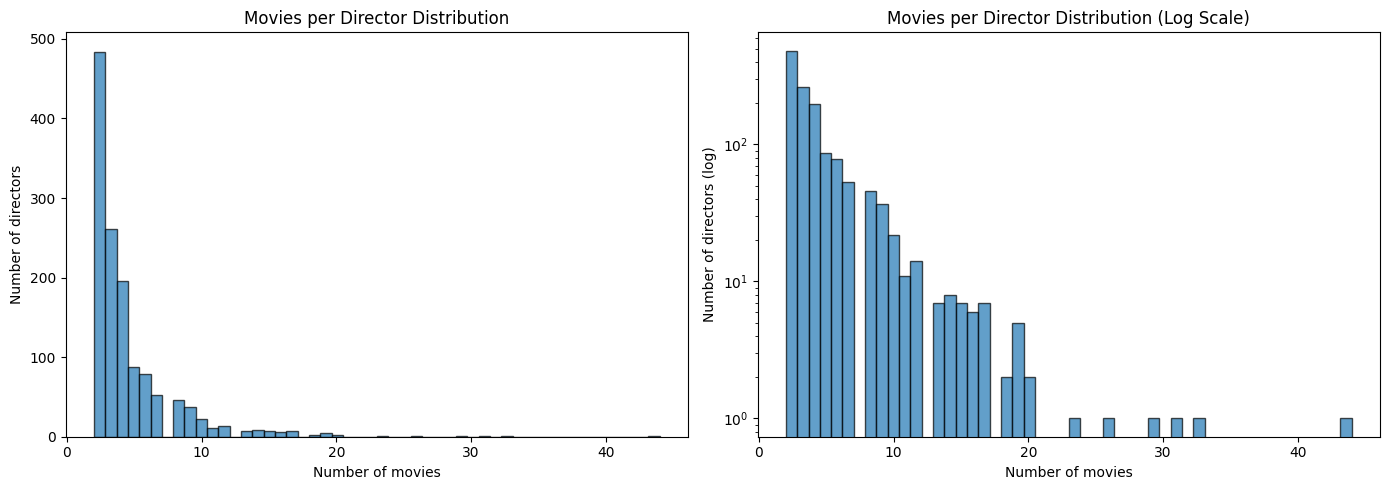

In [15]:
# 5-2. 감독당 영화 수 분포
movies_per_director = directors.groupby('director')['item'].nunique()

print("=" * 60)
print("[감독당 영화 수 분포]")
print(f"평균: {movies_per_director.mean():.2f}")
print(f"중앙값: {movies_per_director.median():.0f}")
print(f"최소: {movies_per_director.min()}")
print(f"최대: {movies_per_director.max()}")

print("\nPercentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}%: {movies_per_director.quantile(p/100):.0f}")

# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(movies_per_director, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of movies')
axes[0].set_ylabel('Number of directors')
axes[0].set_title('Movies per Director Distribution')

axes[1].hist(movies_per_director, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of movies')
axes[1].set_ylabel('Number of directors (log)')
axes[1].set_title('Movies per Director Distribution (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [16]:
# 5-3. 다작 감독 Top 20
top_directors = movies_per_director.sort_values(ascending=False).head(20)

print("=" * 60)
print("[다작 감독 Top 20]")
for i, (director, count) in enumerate(top_directors.items(), 1):
    print(f"  {i}. {director}: {count}편")

[다작 감독 Top 20]
  1. nm0000095: 44편
  2. nm0000033: 33편
  3. nm0000142: 31편
  4. nm0000229: 29편
  5. nm0000217: 26편
  6. nm0001752: 23편
  7. nm0000165: 20편
  8. nm0943758: 20편
  9. nm0000631: 19편
  10. nm0000697: 19편
  11. nm0001379: 19편
  12. nm0000041: 19편
  13. nm0000005: 19편
  14. nm0001469: 18편
  15. nm0001348: 18편
  16. nm0000776: 17편
  17. nm0000591: 17편
  18. nm0001328: 17편
  19. nm0001149: 17편
  20. nm0000318: 17편


In [17]:
# 5-4. 아이템당 감독 수 (공동 감독 확인)
directors_per_item = directors.groupby('item')['director'].nunique()

print("=" * 60)
print("[아이템당 감독 수 분포]")
director_count_dist = directors_per_item.value_counts().sort_index()
for n_dir, count in director_count_dist.items():
    print(f"  {n_dir}명: {count}개 아이템 ({count/len(directors_per_item)*100:.1f}%)")

[아이템당 감독 수 분포]
  1명: 5220개 아이템 (94.9%)
  2명: 225개 아이템 (4.1%)
  3명: 37개 아이템 (0.7%)
  4명: 8개 아이템 (0.1%)
  5명: 3개 아이템 (0.1%)
  6명: 4개 아이템 (0.1%)
  7명: 3개 아이템 (0.1%)
  8명: 1개 아이템 (0.0%)
  10명: 1개 아이템 (0.0%)
  14명: 1개 아이템 (0.0%)


---
## 6. Writer 분포 분석

In [18]:
# 6-1. 작가 기본 통계
print("=" * 60)
print("[Writer 분포]")
n_writers = writers['writer'].nunique()
n_items_with_writer = writers['item'].nunique()
print(f"고유 작가 수: {n_writers:,}")
print(f"작가 정보가 있는 아이템 수: {n_items_with_writer:,}")

[Writer 분포]
고유 작가 수: 2,989
작가 정보가 있는 아이템 수: 5,648


[작가당 영화 수 분포]
평균: 3.78
중앙값: 3
최소: 2
최대: 47

Percentiles:
  50%: 3
  75%: 4
  90%: 7
  95%: 9
  99%: 16


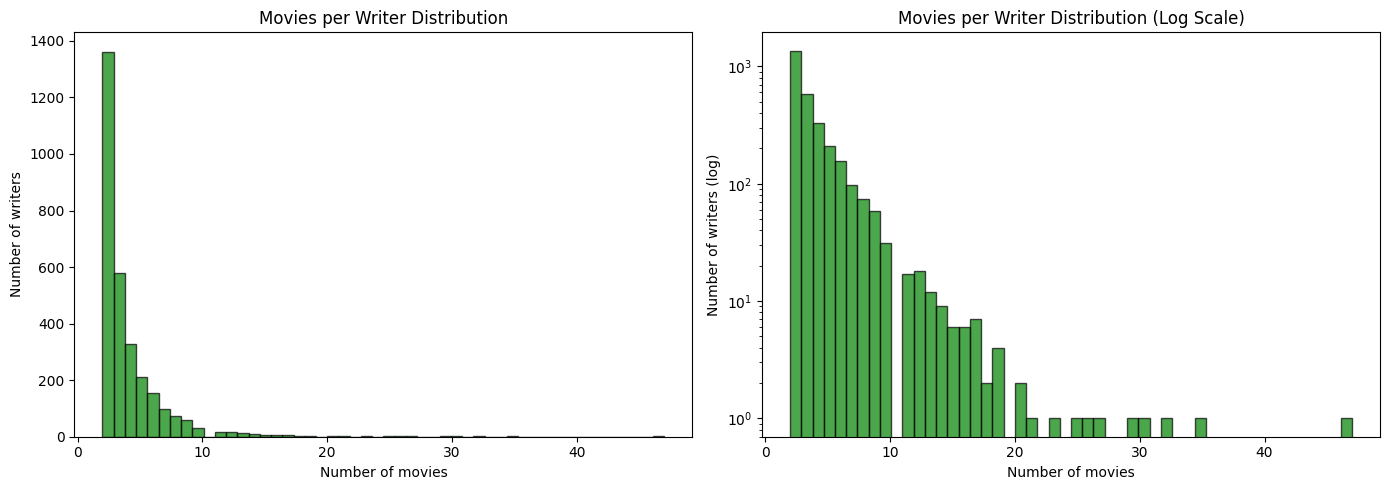

In [19]:
# 6-2. 작가당 영화 수 분포
movies_per_writer = writers.groupby('writer')['item'].nunique()

print("=" * 60)
print("[작가당 영화 수 분포]")
print(f"평균: {movies_per_writer.mean():.2f}")
print(f"중앙값: {movies_per_writer.median():.0f}")
print(f"최소: {movies_per_writer.min()}")
print(f"최대: {movies_per_writer.max()}")

print("\nPercentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}%: {movies_per_writer.quantile(p/100):.0f}")

# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(movies_per_writer, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].set_xlabel('Number of movies')
axes[0].set_ylabel('Number of writers')
axes[0].set_title('Movies per Writer Distribution')

axes[1].hist(movies_per_writer, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Number of movies')
axes[1].set_ylabel('Number of writers (log)')
axes[1].set_title('Movies per Writer Distribution (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [20]:
# 6-3. 다작 작가 Top 20
top_writers = movies_per_writer.sort_values(ascending=False).head(20)

print("=" * 60)
print("[다작 작가 Top 20]")
for i, (writer, count) in enumerate(top_writers.items(), 1):
    print(f"  {i}. {writer}: {count}편")

[다작 작가 Top 20]
  1. nm0000095: 47편
  2. nm0000636: 35편
  3. nm0000175: 32편
  4. nm0372942: 30편
  5. nm0000108: 29편
  6. nm0000697: 27편
  7. nm0000455: 26편
  8. nm0001220: 25편
  9. nm0000041: 23편
  10. nm0744429: 21편
  11. nm0462895: 20편
  12. nm0254645: 20편
  13. nm0436543: 19편
  14. nm0000519: 19편
  15. nm0001279: 19편
  16. nm0004170: 19편
  17. nm0000005: 18편
  18. nm0000118: 18편
  19. nm0000231: 17편
  20. nm0537363: 17편


In [21]:
# 6-4. 아이템당 작가 수 (공동 작가 확인)
writers_per_item = writers.groupby('item')['writer'].nunique()

print("=" * 60)
print("[아이템당 작가 수 분포]")
print(f"평균: {writers_per_item.mean():.2f}")
print(f"중앙값: {writers_per_item.median():.0f}")
print(f"최소: {writers_per_item.min()}")
print(f"최대: {writers_per_item.max()}")

print("\n작가 수별 아이템 분포 (상위 10개):")
writer_count_dist = writers_per_item.value_counts().sort_index()
for n_wr, count in list(writer_count_dist.items())[:10]:
    print(f"  {n_wr}명: {count}개 아이템 ({count/len(writers_per_item)*100:.1f}%)")

[아이템당 작가 수 분포]
평균: 2.00
중앙값: 2
최소: 1
최대: 24

작가 수별 아이템 분포 (상위 10개):
  1명: 2660개 아이템 (47.1%)
  2명: 1681개 아이템 (29.8%)
  3명: 699개 아이템 (12.4%)
  4명: 323개 아이템 (5.7%)
  5명: 137개 아이템 (2.4%)
  6명: 67개 아이템 (1.2%)
  7명: 26개 아이템 (0.5%)
  8명: 17개 아이템 (0.3%)
  9명: 11개 아이템 (0.2%)
  10명: 8개 아이템 (0.1%)


---
## 7. 요약

In [22]:
print("=" * 60)
print("[Step 2 단변량 분석 요약]")
print("=" * 60)

print("\n1. 유저/아이템 분포")
print("   - 둘 다 전형적인 Long-tail 분포")
print(f"   - 상위 10% 아이템이 전체 상호작용의 약 {item_counts_sorted.head(int(len(item_counts_sorted)*0.1)).sum()/total_interactions*100:.1f}% 차지")
print(f"   - 상위 10% 유저가 전체 상호작용의 약 {user_counts_sorted.head(int(len(user_counts_sorted)*0.1)).sum()/total_interactions*100:.1f}% 차지")

print("\n2. Time 분포")
print(f"   - 데이터 수집 기간: {ratings['datetime'].min().year} ~ {ratings['datetime'].max().year}")
print(f"   - 가장 상호작용 많은 연도: {year_counts.idxmax()} ({year_counts.max():,}건)")
print(f"   - 가장 상호작용 많은 시간대: Evening (18-24)" if time_periods['Evening (18-24)'] == max(time_periods.values()) else "")

print("\n3. Genre 분포")
print(f"   - 총 장르 수: {genres['genre'].nunique()}개")
print(f"   - 가장 많은 장르: {genre_item_counts.index[0]} ({genre_item_counts.values[0]}개 아이템)")
print(f"   - 아이템당 평균 장르 수: {genres_per_item.mean():.2f}개")

print("\n4. Year (개봉연도) 분포")
print(f"   - 개봉연도 범위: {years['year'].min()} ~ {years['year'].max()}")
print(f"   - 가장 많은 연대: {decade_counts.idxmax()}s ({decade_counts.max()}편)")

print("\n5. Director 분포")
print(f"   - 고유 감독 수: {n_directors:,}명")
print(f"   - 감독당 평균 영화 수: {movies_per_director.mean():.2f}편")
print(f"   - 공동 감독 영화 비율: {(directors_per_item > 1).sum() / len(directors_per_item) * 100:.1f}%")

print("\n6. Writer 분포")
print(f"   - 고유 작가 수: {n_writers:,}명")
print(f"   - 작가당 평균 영화 수: {movies_per_writer.mean():.2f}편")
print(f"   - 아이템당 평균 작가 수: {writers_per_item.mean():.2f}명")

[Step 2 단변량 분석 요약]

1. 유저/아이템 분포
   - 둘 다 전형적인 Long-tail 분포
   - 상위 10% 아이템이 전체 상호작용의 약 61.0% 차지
   - 상위 10% 유저가 전체 상호작용의 약 31.4% 차지

2. Time 분포
   - 데이터 수집 기간: 2005 ~ 2015
   - 가장 상호작용 많은 연도: 2008 (679,269건)
   - 가장 상호작용 많은 시간대: Evening (18-24)

3. Genre 분포
   - 총 장르 수: 18개
   - 가장 많은 장르: Drama (3490개 아이템)
   - 아이템당 평균 장르 수: 2.34개

4. Year (개봉연도) 분포
   - 개봉연도 범위: 1922 ~ 2014
   - 가장 많은 연대: 2000s (2477편)

5. Director 분포
   - 고유 감독 수: 1,340명
   - 감독당 평균 영화 수: 4.41편
   - 공동 감독 영화 비율: 5.1%

6. Writer 분포
   - 고유 작가 수: 2,989명
   - 작가당 평균 영화 수: 3.78편
   - 아이템당 평균 작가 수: 2.00명
